In [1]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import welch
from tqdm.notebook import tqdm
import pywt
import cv2
from skimage.draw import polygon2mask
from skimage.measure import find_contours

In [ ]:
# -----------------------------
# ROI mask helpers (V1 outline)
# -----------------------------
def make_v1_mask(movie_shape_hw, raw_outlines, binning, spaceorigin, flip=True, v1_index=37):
    """
    Returns boolean mask (H,W) for V1 based on allenMapEdgeOutline.
    movie_shape_hw: (H, W)
    raw_outlines: array like (Nroi, 2, Npoints) after squeeze
    """
    spaceorigin = (spaceorigin - 1) / binning + 1

    outlines = raw_outlines / binning
    outlines[:, 0, :] -= spaceorigin[1] - 1  # Y
    outlines[:, 1, :] -= spaceorigin[0] - 1  # X

    outline = outlines[v1_index, :, :]  # (2, N)

    valid = ~np.isnan(outline).any(axis=0)
    x = outline[1, valid]
    y = outline[0, valid]

    mask = polygon2mask(movie_shape_hw, np.column_stack((y, x))).astype(bool)

    if flip:
        mask = np.flipud(mask)

    return mask


def load_movie_and_v1_mask(mouse, date, file):
    """
    Loads denoised movie into memory and returns:
      movie: float32, shape (T,H,W)
      fps: float
      v1_mask: bool, shape (H,W)
    Applies your flip rules to the movie and mask consistently.
    """
    base = f"Y:/Voltage/VisualConsciousness/Analysis/Visual/{mouse}/20{date}/{file}"
    noisy_path = f"{base}/cG_unmixed_dFF.h5"

    if mouse in ("cfm001mjr", "cfm002mjr"):
        denoised_path = f"{base}/cG_unmixed_dFF_denoised_2.h5"
    else:
        denoised_path = f"{base}/cG_unmixed_dFF_denoised.h5"

    with h5py.File(noisy_path, "r") as f:
        fps = float(f["specs"]["fps"][()].squeeze())

    with h5py.File(denoised_path, "r") as f:
        specs = f["specs"]
        binning = specs["binning"][()].squeeze()
        raw_outlines = specs["extra_specs"]["allenMapEdgeOutline"][()].squeeze()
        spaceorigin = specs["spaceorigin"][()].squeeze()

        movie = np.nan_to_num(f["mov"][()], copy=False).astype(np.float32, copy=False)

    # Your flip rules
    flipud_mask = mouse in ("cfm001mjr","cfm002mjr","cmm002mjr","cmm003mjr","rfm001mjr","rfm002mjr","rfm003mjr")

    if mouse in ("cfm003mjr", "cfm004mjr", "cmm001mjr"):
        # You flipped axis=1 in your code (i.e., H dimension if movie is (T,H,W))
        movie = np.flip(movie, axis=1)
        flipud_mask = True

    v1_mask = make_v1_mask(movie.shape[1:3], raw_outlines, binning, spaceorigin, flip=flipud_mask, v1_index=37)
    return movie, fps, v1_mask


# -----------------------------
# Trial grouping + filtering
# -----------------------------
def assign_trial_group(trialtype_value):
    """
    Maps your TrialType values into the 8 groups you want.
    Your csv must have a column 'TrialType' that matches these strings.
    """
    if trialtype_value == "HC Hit (3)":
        return "HC Hit"
    if trialtype_value == "HC No Report (7)":
        return "HC No Report"
    if trialtype_value == "MC Hit (2)":
        return "MC Hit"
    if trialtype_value == "MC Miss (5)":
        return "MC Miss"
    if trialtype_value == "MC No Report (8)":
        return "MC No Report"
    if trialtype_value == "False Alarm (1)":
        return "False Alarm"
    if trialtype_value == "Correct Rejection (4)":
        return "Correct Rejection"
    return None


def _next_pow2(n: int) -> int:
    n = int(n)
    if n <= 1:
        return 1
    return 1 << (n - 1).bit_length()


def power_spectrum_welch(signal_1d, fps, fmax=70.0, seglen_sec=0.5):
    x = np.asarray(signal_1d, dtype=float)
    x = x - np.nanmean(x)

    nperseg = max(8, int(round(seglen_sec * fps)))
    nperseg = min(nperseg, x.size)
    if nperseg < 8:
        return None, None

    nfft = _next_pow2(nperseg)

    freqs, psd = welch(
        x,
        fs=fps,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        nfft=nfft,
        detrend="constant",
        scaling="density",
        average="mean",
    )

    keep = (freqs >= 0) & (freqs <= fmax)
    return freqs[keep], psd[keep]


# -----------------------------
# Main compute: one load per recording
# -----------------------------
def compute_mouse_power_spectra_all_groups(mouse_name, trial_info_file, fmax=70.0, peri_sec=0.5, y_mode="dB"):
    """
    Loads each recording once. For that recording:
      - compute roi_ts once
      - loop all trials in that recording and accumulate PSDs by group + epoch

    Returns:
      results[group][epoch] = dict(freqs=..., mean_psd=..., n=...)
    Also plots one figure per group at the end.
    """
    df_all = pd.read_csv(trial_info_file)

    # Keep only valid trials for this mouse
    df = df_all[df_all["ValidTrial?"] == True].copy()
    df = df[df["AnimalCode"] == mouse_name].copy()

    # Assign group
    df["TrialGroup"] = df["TrialType"].apply(assign_trial_group)
    df = df[df["TrialGroup"].notna()].copy()

    if len(df) == 0:
        print("No trials found after filtering.")
        return None

    # Group trials by recording
    rec_keys = ["AnimalCode", "Date", "File"]
    recordings = df[rec_keys].drop_duplicates().reset_index(drop=True)

    print(f"Mouse: {mouse_name}")
    print(f"Valid trials (in groups): {len(df)}")
    print(f"Unique recordings: {len(recordings)}")

    groups = [
        "HC Hit", "HC Miss",
        "MC Hit", "MC Miss", "MC No Report",
        "False Alarm", "Correct Rejection", "HC No Report"
    ]
    epochs = ["pre", "stim", "post"]

    # Accumulators: dict[group][epoch] -> list of psd arrays
    acc = {g: {e: [] for e in epochs} for g in groups}
    counts_used = {g: {e: 0 for e in epochs} for g in groups}
    counts_omitted_trials = 0
    omitted_recordings = []

    freqs_ref = None

    for _, rec in tqdm(recordings.iterrows(), total=len(recordings), desc="Recordings"):
        mouse = rec["AnimalCode"]
        date = rec["Date"]
        file = rec["File"]

        # all trials in this recording
        df_rec = df[(df["AnimalCode"] == mouse) & (df["Date"] == date) & (df["File"] == file)]

        try:
            movie, fps, v1_mask = load_movie_and_v1_mask(mouse, date, file)
        except Exception as e:
            omitted_recordings.append(f"{date}/{file}")
            continue

        # Fast ROI mean time series once
        # movie: (T,H,W), mask: (H,W) -> (T, Npix) -> mean -> (T,)
        roi_ts = movie[:, v1_mask].mean(axis=1)

        # For each trial, compute 3 PSDs and accumulate into its group
        for _, trial in df_rec.iterrows():
            bfm = float(trial["BFMTime"])
            dur = float(trial["Duration"])
            group = trial["TrialGroup"]

            # time windows (seconds)
            t_pre0, t_pre1 = bfm - peri_sec, bfm
            t_st0,  t_st1  = bfm, bfm + dur
            t_po0,  t_po1  = bfm + dur, bfm + dur + peri_sec

            # frames
            s0 = int(np.floor(t_pre0 * fps))
            s1 = int(np.floor(t_pre1 * fps))
            a0 = int(np.floor(t_st0  * fps))
            a1 = int(np.floor(t_st1  * fps))
            p0 = int(np.floor(t_po0  * fps))
            p1 = int(np.floor(t_po1  * fps))

            # bounds
            if s0 < 0 or p1 >= roi_ts.shape[0] or s1 <= s0 or a1 <= a0 or p1 <= p0:
                counts_omitted_trials += 1
                continue

            pre_sig  = roi_ts[s0:s1]
            stim_sig = roi_ts[a0:a1]
            post_sig = roi_ts[p0:p1]

            f_pre,  psd_pre  = power_spectrum_welch(pre_sig,  fps, fmax=fmax, seglen_sec=peri_sec)
            f_stim, psd_stim = power_spectrum_welch(stim_sig, fps, fmax=fmax, seglen_sec=peri_sec)
            f_post, psd_post = power_spectrum_welch(post_sig, fps, fmax=fmax, seglen_sec=peri_sec)

            if f_pre is None or f_stim is None or f_post is None:
                counts_omitted_trials += 1
                continue

            # Set/refine frequency grid once, interpolate if needed
            if freqs_ref is None:
                freqs_ref = f_pre

            if not np.array_equal(freqs_ref, f_pre):
                psd_pre = np.interp(freqs_ref, f_pre, psd_pre)
            if not np.array_equal(freqs_ref, f_stim):
                psd_stim = np.interp(freqs_ref, f_stim, psd_stim)
            if not np.array_equal(freqs_ref, f_post):
                psd_post = np.interp(freqs_ref, f_post, psd_post)

            acc[group]["pre"].append(psd_pre);   counts_used[group]["pre"] += 1
            acc[group]["stim"].append(psd_stim); counts_used[group]["stim"] += 1
            acc[group]["post"].append(psd_post); counts_used[group]["post"] += 1

    print("\nDone accumulating.")
    print(f"Omitted recordings: {len(omitted_recordings)}")
    print(f"Omitted trials (bounds/PSD issues): {counts_omitted_trials}")

    # Build results and plot
    results = {}
    eps = 1e-20

    for g in groups:
        results[g] = {}
        plt.figure(figsize=(6.5, 4.0))

        for epoch, label in [("pre", "Pre"), ("stim", "Stim"), ("post", "Post")]:
            if len(acc[g][epoch]) == 0:
                results[g][epoch] = {"freqs": freqs_ref, "mean_psd": None, "n": 0}
                continue

            arr = np.vstack(acc[g][epoch])
            mean_psd = arr.mean(axis=0)
            results[g][epoch] = {"freqs": freqs_ref, "mean_psd": mean_psd, "n": arr.shape[0]}

            if y_mode == "dB":
                plt.plot(freqs_ref, 10*np.log10(mean_psd + eps), label=f"{label} (n={arr.shape[0]})")
                plt.ylabel("PSD (dB/Hz)")
            elif y_mode == "log":
                plt.semilogy(freqs_ref, mean_psd, label=f"{label} (n={arr.shape[0]})")
                plt.ylabel("PSD")
            else:
                plt.plot(freqs_ref, mean_psd, label=f"{label} (n={arr.shape[0]})")
                plt.ylabel("PSD")

        plt.xlabel("Frequency (Hz)")
        plt.title(f"{mouse_name} – {g} – V1 mean power spectra")
        plt.grid(True, alpha=0.3)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    return results

Mouse: cfm002mjr
Valid trials (in groups): 1601
Unique recordings: 18


Recordings:   0%|          | 0/18 [00:00<?, ?it/s]


Done accumulating.
Omitted recordings: 0
Omitted trials (bounds/PSD issues): 1


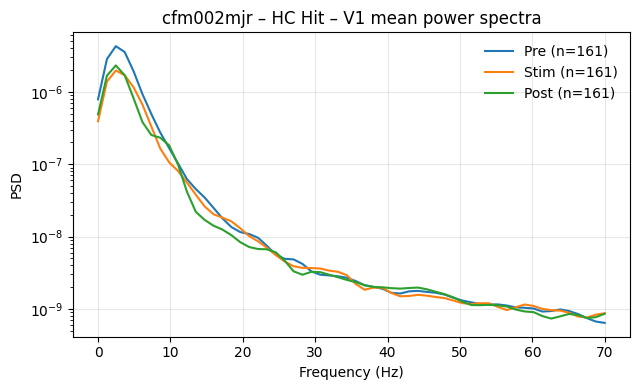

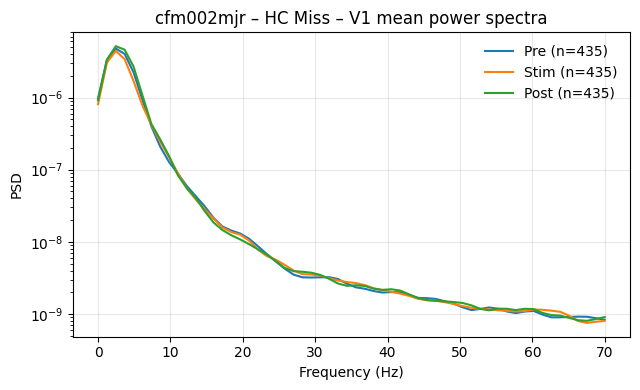

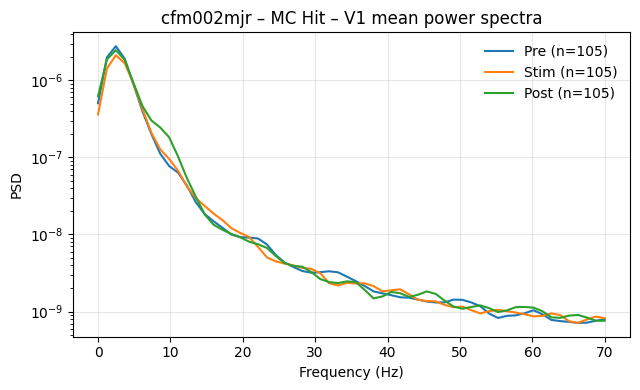

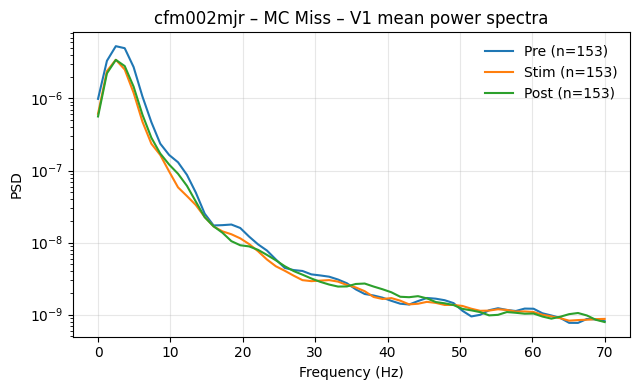

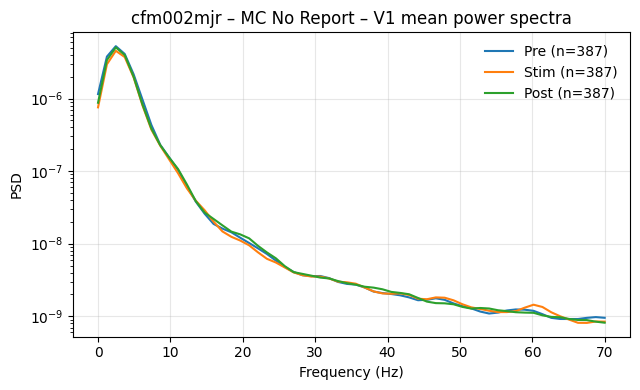

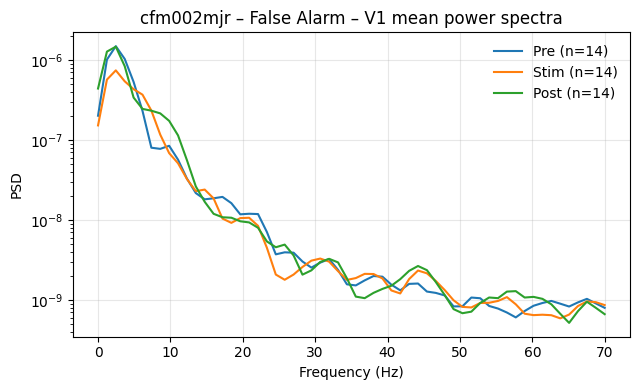

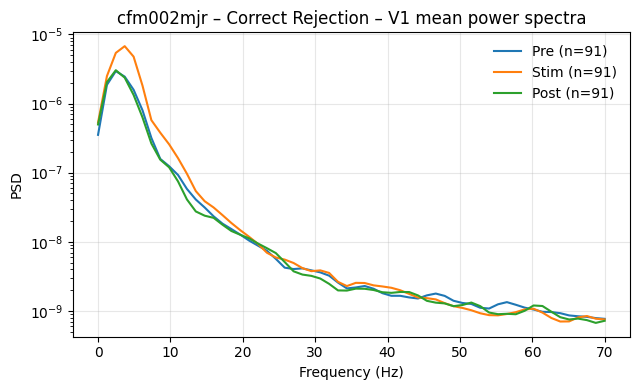

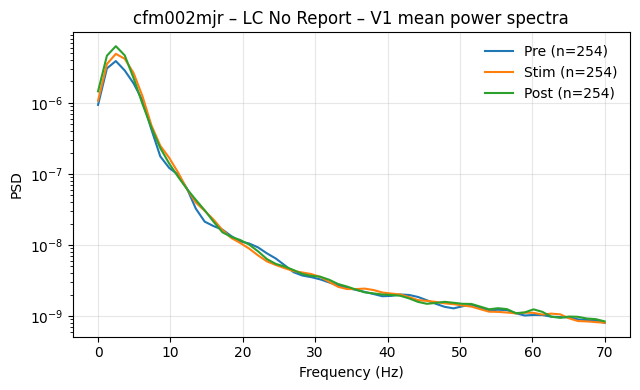

In [ ]:
# Example
results = compute_mouse_power_spectra_all_groups(
    mouse_name="cfm002mjr",
    trial_info_file="trial_info/TrialInfo_cfm002mjr.csv",
    fmax=70.0,
    peri_sec=0.5,
    y_mode="log",
)

In [ ]:
results = compute_mouse_power_spectra_all_groups(
    mouse_name="cfm001mjr",
    trial_info_file="trial_info/TrialInfo_cfm001mjr.csv",
    fmax=70.0,
    peri_sec=0.5,
    y_mode="log",
)

Mouse: cfm001mjr
Valid trials (in groups): 1850
Unique recordings: 21


Recordings:   0%|          | 0/21 [00:00<?, ?it/s]